In [1]:
from unet1 import UNet
from testing_model import LightningModel
from helper_functions import *
from testing_functions import *
from torchmetrics.image import StructuralSimilarityIndexMeasure
import csv
import string
ssim = StructuralSimilarityIndexMeasure(data_range=1.0)

In [2]:
test_path_multi = "../../Datasets/3hz/Multi/test_set_256.npz"
train_path_multi = "../../Datasets/3hz/Multi/train_set_256.npz"
val_path_multi = "../../Datasets/3hz/Multi/valid_set_256.npz"

test_path_single = "../../Datasets/3hz/Single/test_set_256.npz"
train_path_single = "../../Datasets/3hz/Single/train_set_256.npz"
val_path_single = "../../Datasets/3hz/Single/valid_set_256.npz"


In [3]:
model_pth_mouse='../final_model_weight/PAOmniNet/PA_OmniNet_Generalized.pth'
model_pth_multi ='../final_model_weight/3hz/PA_OmniNet_3hzMulti.pth'
model_pth_single = '../final_model_weight/3hz/PA_OmniNet_3hzSingle.pth'
hparams = {
    "batch_size": 32,
    "learning_rate": 1e-4,
    "nb_levels": 4,
    "nb_inner_channels": 32,
    "nb_conv_layers_per_stage": 2,
    "data_slice_only": True,
    "max_epochs": 250,
}
model = LightningModel(hparams)
state_dict = torch.load(model_pth_mouse, map_location=torch.device('cpu'))
model.load_state_dict(state_dict)

NeuralizerMulti = LightningModel(hparams)
state_dict = torch.load(model_pth_multi, map_location=torch.device('cpu'))
NeuralizerMulti.load_state_dict(state_dict)

NeuralizerSingle = LightningModel(hparams)
state_dict = torch.load(model_pth_single, map_location=torch.device('cpu'))
NeuralizerSingle.load_state_dict(state_dict)

Unet3hzMulti = '../final_model_weight/3hz/Unet_3hz_Multi.pth'
Unet3hzMultiModel = UNet()
Unet3hzMultiModel.load_state_dict(torch.load(Unet3hzMulti, map_location=torch.device('cpu')))
Unet3hzMultiModel.eval()  

Unet3hzSingle = '../final_model_weight/3hz/Unet_3hz_Single.pth'
Unet3hzSingleModel = UNet()
Unet3hzSingleModel.load_state_dict(torch.load(Unet3hzSingle, map_location=torch.device('cpu')))
Unet3hzSingleModel.eval()

UnetSWFDSemi = '../final_model_weight/Unet/Unet_Generalized.pth'
Unet_Semi_model = UNet()
Unet_Semi_model.load_state_dict(torch.load(UnetSWFDSemi, map_location=torch.device('cpu')))
Unet_Semi_model.eval()  
print('Loaded')

C:\Users\olivi\AppData\Local\Temp\ipykernel_347332\3194740563.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_pth_mouse, map_location=torc

Loaded


C:\Users\olivi\AppData\Local\Temp\ipykernel_347332\3194740563.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Unet_Semi_model.load_state_dict(torch.load(UnetSWFDSemi, m

In [4]:
def preprocess_Unet(image, size=(256, 256)):
    image = (image - image.min()) / (image.max() - image.min())
    image = torch.tensor(image)
    image = image.unsqueeze(0)
    return image

def preprocess_batch_Unet(images, size=(256, 256)):
    processed_images = []
    for image in images:
        processed_image = preprocess_Unet(image, size)
        processed_images.append(processed_image)
    return torch.cat(processed_images, dim=0)

def data_loader_formatter(filepath):
    data = np.load(filepath)
    data_in = data['arr_0']
    data_out = data['arr_1']
    return data_in, data_out

In [5]:
def preprocess_mat_Neuralizer(image, size=(256, 256)):
    image = (image - image.min()) / (image.max() - image.min())
    # image = cv2.resize(image, size, interpolation=cv2.INTER_LINEAR)
    image = np.stack([image] * 3, axis=-1)
    image = torch.tensor(image)
    image = image.unsqueeze(0)
    image = image.permute(0, 3, 1, 2).float()
    return image

def preprocess_batch_Neuralizer(images, size=(256, 256)):
    processed_images = []
    for image in images:
        processed_image = preprocess_mat_Neuralizer(image, size)
        processed_images.append(processed_image)
    return torch.cat(processed_images, dim=0)

In [6]:
CONTEXT_SIZE = 16
X_test, y_test = data_loader_formatter(test_path_multi)
X_train, y_train = data_loader_formatter(train_path_multi)

X_train_Neur = preprocess_batch_Neuralizer(X_train)
y_train_Neur = preprocess_batch_Neuralizer(y_train)
X_train_Unet = preprocess_batch_Unet(X_train)
y_train_Unet = preprocess_batch_Unet(y_train)

X_test_Unet = preprocess_batch_Unet(X_test)
y_test_Unet = preprocess_batch_Unet(y_test)
X_test_Unet = X_test_Unet
y_test_Unet =y_test_Unet
X_context = X_train_Neur[:CONTEXT_SIZE]
y_context = y_train_Neur[:CONTEXT_SIZE]

X_test_Neur = preprocess_batch_Neuralizer(X_test)
y_test_Neur = preprocess_batch_Neuralizer(y_test)
X_test_Neur = X_test_Neur
y_test_Neur = y_test_Neur
print(f'In this order:\nX_test_Neur = {X_test_Neur.unsqueeze(0).shape}, y_test_Neur = {y_test_Neur.unsqueeze(0).shape}, X_context = {X_context.unsqueeze(0).shape}, y_context = {y_context.unsqueeze(0).shape}\n'
      f'X_test_Unet = {X_test_Unet.unsqueeze(0).shape}, y_test_Unet = {y_test_Unet.unsqueeze(0).shape}')


In this order:
X_test_Neur = torch.Size([1, 25, 3, 256, 256]), y_test_Neur = torch.Size([1, 25, 3, 256, 256]), X_context = torch.Size([1, 16, 3, 256, 256]), y_context = torch.Size([1, 16, 3, 256, 256])
X_test_Unet = torch.Size([1, 25, 256, 256]), y_test_Unet = torch.Size([1, 25, 256, 256])


In [7]:
def get_all_test_data(train, test :str, CONTEXT_SIZE=16, idx_i=0):
    X_test, y_test = data_loader_formatter(test)
    X_train, y_train = data_loader_formatter(train)

    X_train_Neur = preprocess_batch_Neuralizer(X_train)
    y_train_Neur = preprocess_batch_Neuralizer(y_train)
    X_train_Unet = preprocess_batch_Unet(X_train)
    y_train_Unet = preprocess_batch_Unet(y_train)

    X_test_Unet = preprocess_batch_Unet(X_test)
    y_test_Unet = preprocess_batch_Unet(y_test)
    X_test_Unet = X_test_Unet[idx_i]
    y_test_Unet =y_test_Unet[idx_i]
    X_context = X_train_Neur[:CONTEXT_SIZE]
    y_context = y_train_Neur[:CONTEXT_SIZE]

    X_test_Neur = preprocess_batch_Neuralizer(X_test)
    y_test_Neur = preprocess_batch_Neuralizer(y_test)
    X_test_Neur = X_test_Neur[idx_i]
    y_test_Neur = y_test_Neur[idx_i]
    print(f'In this order:\nX_test_Neur = {X_test_Neur.unsqueeze(0).shape}, y_test_Neur = {y_test_Neur.unsqueeze(0).shape}, X_context = {X_context.unsqueeze(0).shape}, y_context = {y_context.unsqueeze(0).shape}\n'
          f'X_test_Unet = {X_test_Unet.unsqueeze(0).shape}, y_test_Unet = {y_test_Unet.unsqueeze(0).shape}')
    return X_test_Neur.unsqueeze(0), y_test_Neur.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0), X_test_Unet.unsqueeze(0), y_test_Unet.unsqueeze(0)


In [12]:
X_Neuralizer_1, y_Neuralizer_1, X_context_1, y_context_1, X_unet_1, y_unet_1 = get_all_test_data(train_path_single, test_path_single, idx_i=14)
X_Neuralizer_2, y_Neuralizer_2, X_context_2, y_context_2, X_unet_2, y_unet_2 = get_all_test_data(train_path_single, test_path_single,idx_i=3)
X_Neuralizer_3, y_Neuralizer_3, X_context_3, y_context_3, X_unet_3, y_unet_3 = get_all_test_data(train_path_single, test_path_single,idx_i=4)

In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 16, 3, 256, 256]), y_context = torch.Size([1, 16, 3, 256, 256])
X_test_Unet = torch.Size([1, 256, 256]), y_test_Unet = torch.Size([1, 256, 256])
In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 16, 3, 256, 256]), y_context = torch.Size([1, 16, 3, 256, 256])
X_test_Unet = torch.Size([1, 256, 256]), y_test_Unet = torch.Size([1, 256, 256])
In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 16, 3, 256, 256]), y_context = torch.Size([1, 16, 3, 256, 256])
X_test_Unet = torch.Size([1, 256, 256]), y_test_Unet = torch.Size([1, 256, 256])


In [ ]:
# X_Neuralizer_1, y_Neuralizer_1, X_context_1, y_context_1, X_unet_1, y_unet_1 = get_all_test_data(train_path_single, test_path_single, idx_i=14)

Iteration 0:


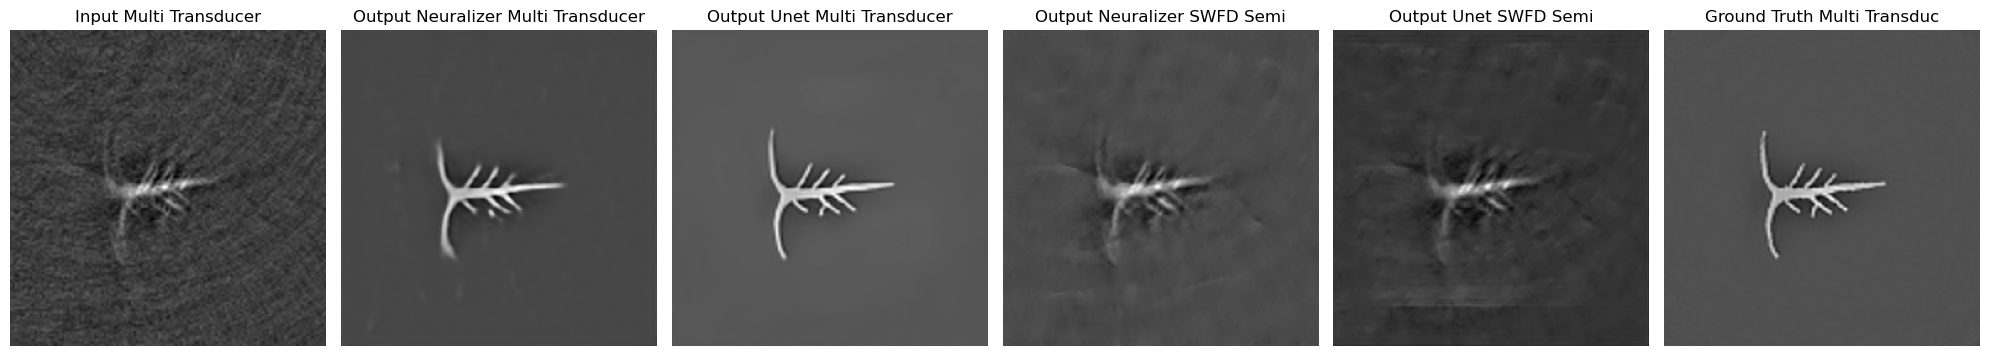

KeyboardInterrupt: 

In [8]:
import os
import matplotlib.pyplot as plt

specific_name = 'Multi Transducer'
specific_model_unet = Unet3hzMultiModel
specific_model_neuralizer = NeuralizerMulti

main_dir = specific_name
os.makedirs(main_dir, exist_ok=True)

# Create subdirectories
subdirs = ['input', 'Generalized U-net', 'Specific U-net', 'Generalized PA OmniNet', 'Specific PA OmniNet', 'Ground Truth']
for subdir in subdirs:
    os.makedirs(os.path.join(main_dir, subdir), exist_ok=True)

for i in range(len(X_test)):
    input_Unet = X_test_Unet[i]
    input_Unet = input_Unet.float()
    input_Unet = input_Unet.unsqueeze(0)
    input_Unet = input_Unet.unsqueeze(0)
    input_Neur = X_test_Neur[i]

    ground_truth_Unet = y_test_Unet[i]
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Neur = y_test_Neur[i]

    output_Neur = model.forward(input_Neur.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))
    output_Neur_specific = specific_model_neuralizer.forward(input_Neur.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))
    output_Unet_Semi = Unet_Semi_model(input_Unet)
    output_Unet_Specific = specific_model_unet(input_Unet)

    normalized_output_Neur = (output_Neur - output_Neur.min()) / (output_Neur.max() - output_Neur.min())
    normalized_output_Semi = (output_Unet_Semi - output_Unet_Semi.min()) / (output_Unet_Semi.max() - output_Unet_Semi.min())
    normalized_output_Neur_specific = (output_Neur_specific - output_Neur_specific.min()) / (output_Neur_specific.max() - output_Neur_specific.min())
    normalized_output_Specific = (output_Unet_Specific - output_Unet_Specific.min()) / (output_Unet_Specific.max() - output_Unet_Specific.min())

    # Convert outputs to numpy arrays and squeeze extra dimensions
    normalized_output_Neur_img = normalized_output_Neur.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    normalized_output_Neur_img_specific = normalized_output_Neur_specific.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    normalized_output_Semi_img = normalized_output_Semi.squeeze().cpu().detach().numpy()
    normalized_output_Specific_img = normalized_output_Specific.squeeze().cpu().detach().numpy()
    ground_truth_img = ground_truth_Unet.squeeze().cpu().numpy()
    input_img = X_test[i].squeeze()
    # print(normalized_output_Neur_img_specific.shape)
    # Debug: Print shapes of images
    print(f"Iteration {i}:")
    # print(f"Input: {input_img.shape}")
    # print(f"Neuralizer: {normalized_output_Neur_img.shape}")
    # print(f"Neuralizer Specific: {normalized_output_Neur_img_specific.shape}")
    # print(f"Unet Semi: {normalized_output_Semi_img.shape}")
    # print(f"Unet Specific: {normalized_output_Specific_img.shape}")
    # print(f"Ground Truth: {ground_truth_img.shape}")

    # Ensure all images are 2D (grayscale)
    if len(input_img.shape) > 2:
        input_img = input_img.mean(axis=-1)  # Convert to grayscale by averaging channels
    if len(normalized_output_Neur_img.shape) > 2:
        normalized_output_Neur_img = normalized_output_Neur_img.mean(axis=-1)
    if len(normalized_output_Neur_img_specific.shape) > 2:
        normalized_output_Neur_img_specific = normalized_output_Neur_img_specific.mean(axis=-1)
    if len(normalized_output_Semi_img.shape) > 2:
        normalized_output_Semi_img = normalized_output_Semi_img.mean(axis=-1)
    if len(normalized_output_Specific_img.shape) > 2:
        normalized_output_Specific_img = normalized_output_Specific_img.mean(axis=-1)
    if len(ground_truth_img.shape) > 2:
        ground_truth_img = ground_truth_img.mean(axis=-1)

    plt.imsave(os.path.join(main_dir, 'input', f'input_{i}.png'), input_img, cmap='gray')
    plt.imsave(os.path.join(main_dir, 'Generalized U-net', f'generalized_unet_{i}.png'), normalized_output_Semi_img, cmap='gray')
    plt.imsave(os.path.join(main_dir, 'Specific U-net', f'specific_unet_{i}.png'), normalized_output_Specific_img, cmap='gray')
    plt.imsave(os.path.join(main_dir, 'Generalized PA OmniNet', f'generalized_pa_omninet_{i}.png'), normalized_output_Neur_img, cmap='gray')
    plt.imsave(os.path.join(main_dir, 'Specific PA OmniNet', f'specific_pa_omninet_{i}.png'), normalized_output_Neur_img_specific, cmap='gray')
    plt.imsave(os.path.join(main_dir, 'Ground Truth', f'ground_truth_{i}.png'), ground_truth_img, cmap='gray')

    # Visualization (optional)
    titles = [f'Input {specific_name}', f'Output Neuralizer {specific_name}',
              f'Output Unet {specific_name}','Output Neuralizer SWFD Semi', 'Output Unet SWFD Semi', f'Ground Truth {specific_name[:-2]}']
    images = [input_img, normalized_output_Neur_img_specific, normalized_output_Specific_img, normalized_output_Neur_img, normalized_output_Semi_img, ground_truth_img]

    plt.figure(figsize=(20, 5))
    for idx, (title, img) in enumerate(zip(titles, images)):
        plt.subplot(1, 6, idx + 1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()




In [10]:
def get_row(X_Neuralizer, y_Neuralizer, context_in, context_out, X_Unet, y_Unet, Neur_specific, Unet_specific):
    input_Unet = X_Unet
    input_Unet = input_Unet.float()
    input_Unet = input_Unet.unsqueeze(0)
    input_Unet = input_Unet.unsqueeze(0)
    input_Neur = X_Neuralizer.unsqueeze(0)

    ground_truth_Unet = y_Unet
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Neur = y_Neuralizer.unsqueeze(0)

    output_Neur_Semi = model.forward(input_Neur, context_in, context_out)
    output_Neur_Semi =(output_Neur_Semi - output_Neur_Semi.min()) / (output_Neur_Semi.max() - output_Neur_Semi.min())

    output_Neur_specific = Neur_specific.forward(input_Neur, context_in, context_out)
    output_Neur_specific = (output_Neur_specific - output_Neur_specific.min()) / (output_Neur_specific.max() - output_Neur_specific.min())

    output_Unet_Semi = Unet_Semi_model(input_Unet.squeeze(0))
    output_Unet_Semi = (output_Unet_Semi - output_Unet_Semi.min()) / (output_Unet_Semi.max() - output_Unet_Semi.min())

    output_Unet_specific = Unet_specific(input_Unet.squeeze(0))
    output_Unet_specific = (output_Unet_specific - output_Unet_specific.min()) / (output_Unet_specific.max() - output_Unet_specific.min())

    rmse_base = compute_rmse(ground_truth_Neur, input_Neur)
    psnr_base = compute_psnr(ground_truth_Neur, input_Neur)
    ssim_base = ssim(ground_truth_Neur.squeeze(1), input_Neur.squeeze(1)).item()
    baseline_metrics = [rmse_base, psnr_base, ssim_base]

    rmse_neur_semi = compute_rmse(ground_truth_Neur.squeeze(0), output_Neur_Semi.squeeze(0))
    psnr_neur_semi = compute_psnr(ground_truth_Neur.squeeze(0), output_Neur_Semi.squeeze(0))
    ssim_neur_semi = ssim(ground_truth_Neur.squeeze(1), output_Neur_Semi).item()
    PA_generalized_metrics = [rmse_neur_semi, psnr_neur_semi, ssim_neur_semi]

    rmse_neur_specific = compute_rmse(ground_truth_Neur.squeeze(0), output_Neur_specific.squeeze(0))
    psnr_neur_specific = compute_psnr(ground_truth_Neur.squeeze(0), output_Neur_specific.squeeze(0))
    ssim_neur_specific = ssim(ground_truth_Neur.squeeze(1), output_Neur_specific).item()
    PA_specific_metrics = [rmse_neur_specific, psnr_neur_specific, ssim_neur_specific]

    rmse_unet_semi = compute_rmse(ground_truth_Unet, output_Unet_Semi)
    psnr_unet_semi = compute_psnr(ground_truth_Unet, output_Unet_Semi)
    ssim_unet_semi = ssim(ground_truth_Unet.squeeze(1), output_Unet_Semi).item()
    Unet_generalized_metrics = [rmse_unet_semi, psnr_unet_semi, ssim_unet_semi]

    rmse_unet_specific = compute_rmse(ground_truth_Unet, output_Unet_specific)
    psnr_unet_specific = compute_psnr(ground_truth_Unet, output_Unet_specific)
    ssim_unet_specific = ssim(ground_truth_Unet.squeeze(1), output_Unet_specific).item()
    Unet_specific_metrics = [rmse_unet_specific, psnr_unet_specific, ssim_unet_specific]

    input_img = input_Unet.squeeze().cpu().detach().numpy()
    PA_generalized_img = output_Neur_Semi.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    PA_specific_img = output_Neur_specific.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    Unet_generalized_img = output_Unet_Semi.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    Unet_specific_img = output_Unet_specific.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
    output_img = ground_truth_Unet.squeeze().cpu().detach().numpy()
    return input_img, Unet_generalized_img, Unet_specific_img, PA_generalized_img, PA_specific_img, output_img, [baseline_metrics, Unet_generalized_metrics, Unet_specific_metrics, PA_generalized_metrics, PA_specific_metrics]


<Figure size 3400x1800 with 0 Axes>

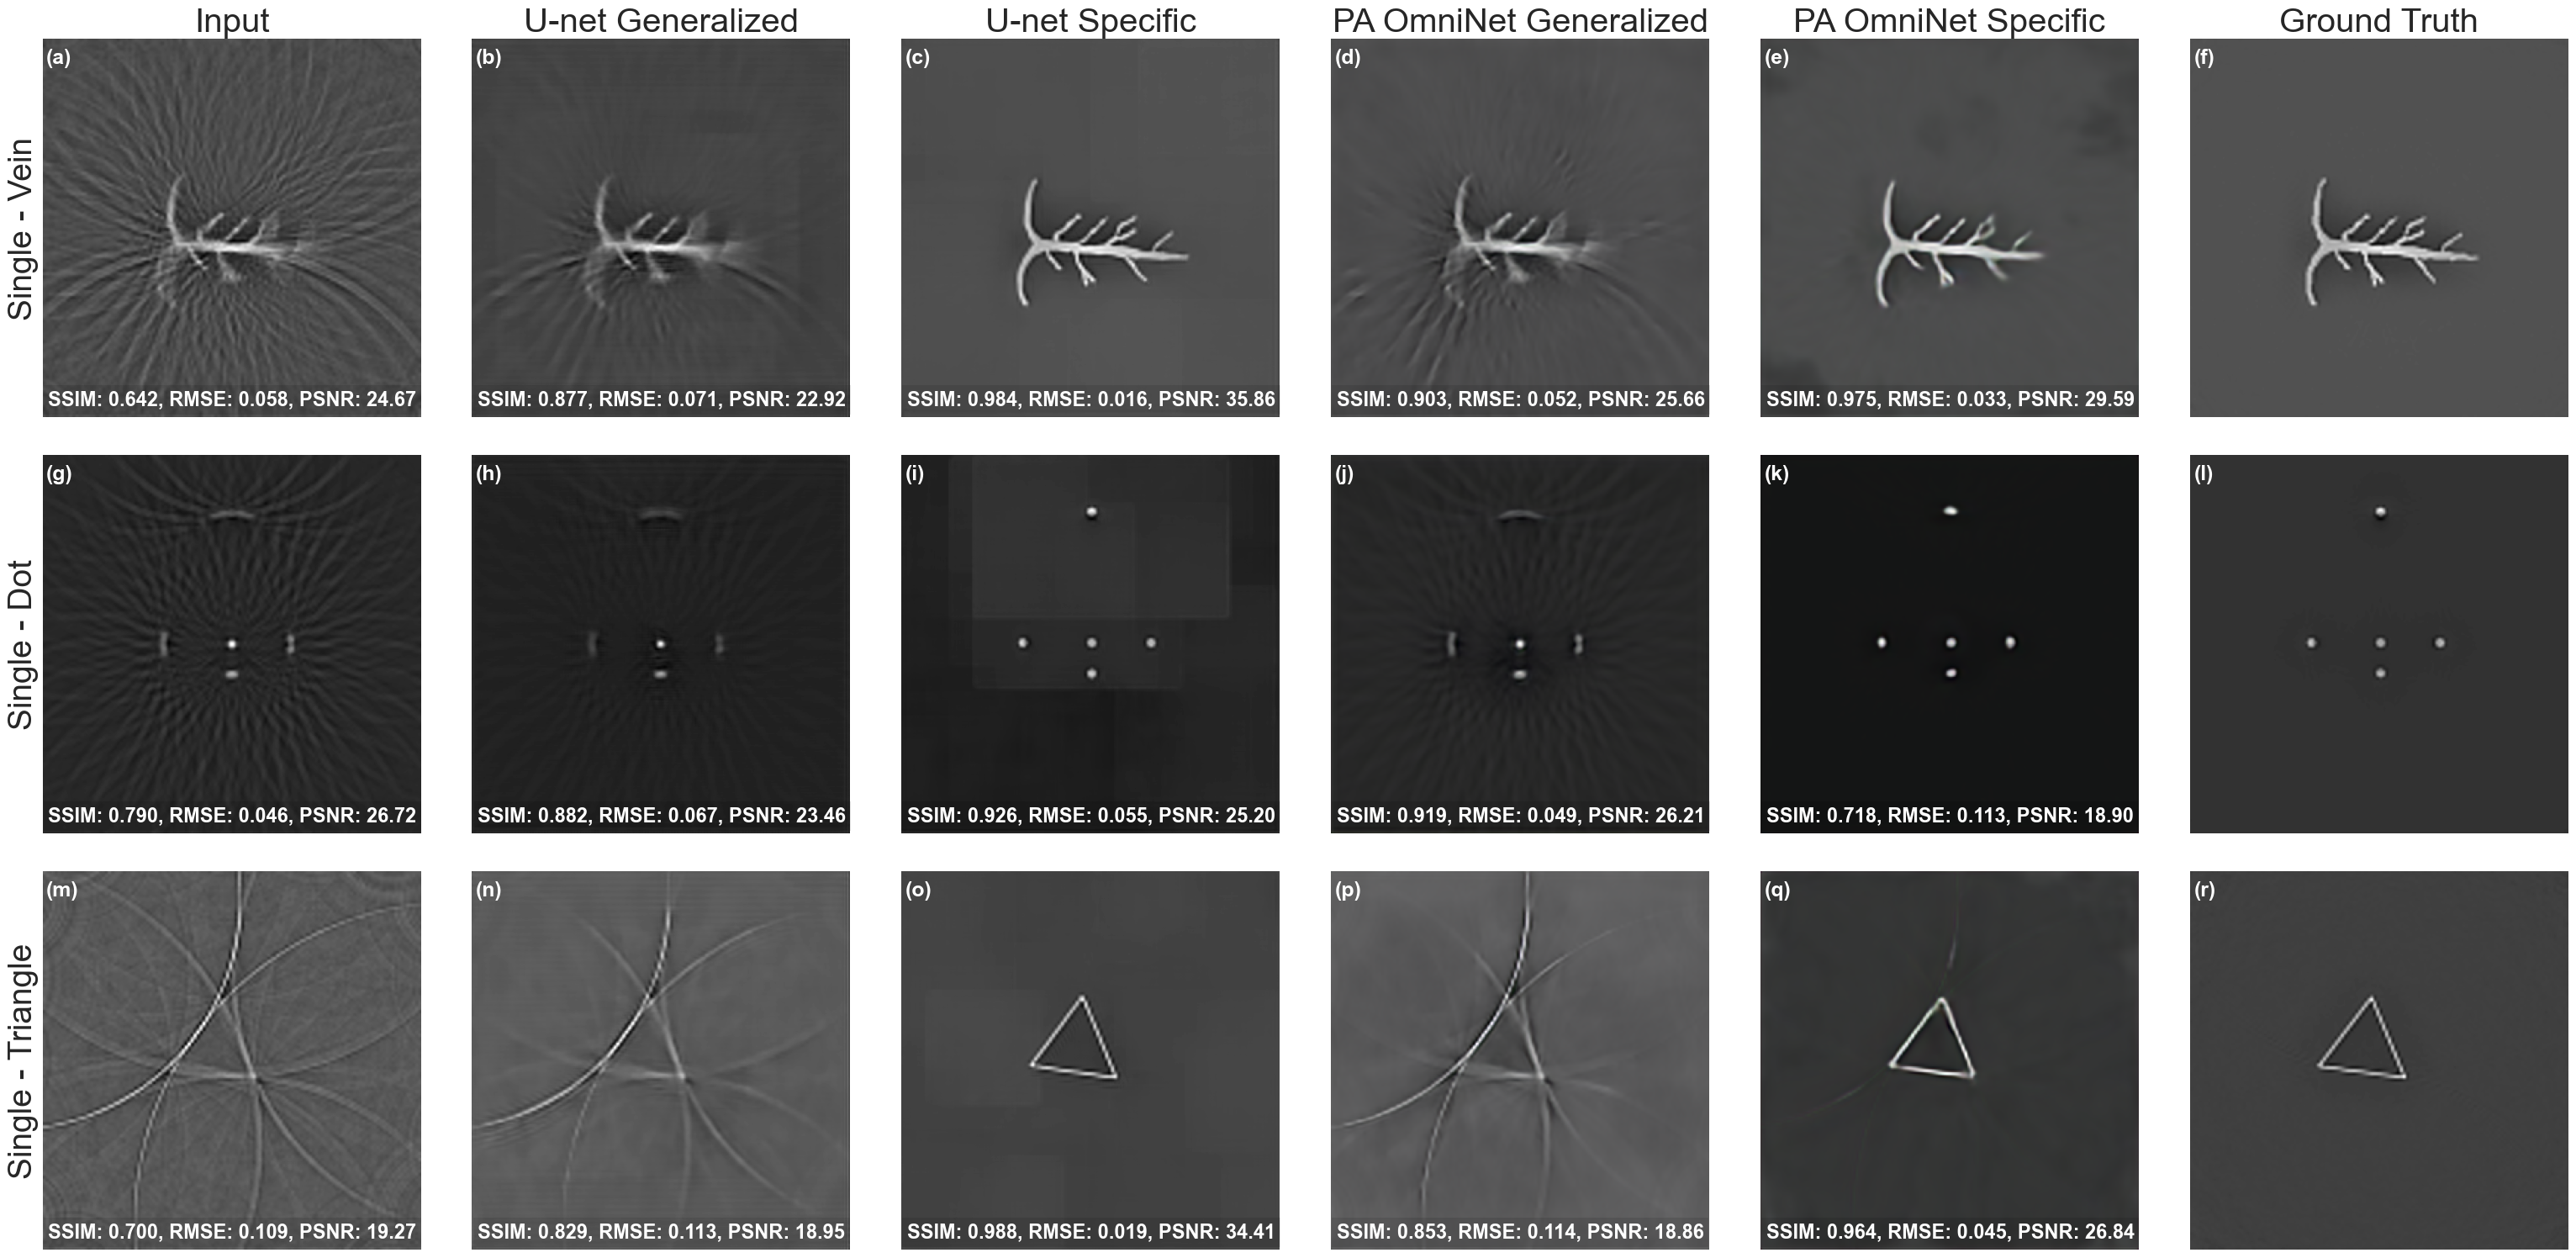

In [12]:

input_img_multi, Unet_generalized_img_multi, Unet_specific_img_multi, PA_generalized_img_multi, PA_specific_img_multi, output_img_multi, [baseline_metrics_multi, Unet_generalized_metrics_multi, Unet_specific_metrics_multi, PA_generalized_metrics_multi, PA_specific_metrics_multi] =(
    get_row(X_Neuralizer_1, y_Neuralizer_1, X_context_1, y_context_1, X_unet_1, y_unet_1, NeuralizerSingle, Unet3hzSingleModel))

input_img_MSFD, Unet_generalized_img_MSFD, Unet_specific_img_MSFD, PA_generalized_img_MSFD, PA_specific_img_MSFD, output_img_MSFD, [baseline_metrics_MSFD, Unet_generalized_metrics_MSFD, Unet_specific_metrics_MSFD, PA_generalized_metrics_MSFD, PA_specific_metrics_MSFD] =(
    get_row(X_Neuralizer_3, y_Neuralizer_3, X_context_3, y_context_3, X_unet_3, y_unet_3, NeuralizerSingle, Unet3hzSingleModel))

input_img_SCD, Unet_generalized_img_SCD, Unet_specific_img_SCD, PA_generalized_img_SCD, PA_specific_img_SCD, output_img_SCD, [baseline_metrics_SCD, Unet_generalized_metrics_SCD, Unet_specific_metrics_SCD, PA_generalized_metrics_SCD, PA_specific_metrics_SCD] =(
    get_row(X_Neuralizer_2, y_Neuralizer_2, X_context_2, y_context_2, X_unet_2, y_unet_2, NeuralizerSingle, Unet3hzSingleModel))

titles = ['Input', 'U-net Generalized', 'U-net Specific', 'PA OmniNet Generalized', 'PA OmniNet Specific', 'Ground Truth']
images = [input_img_multi, Unet_generalized_img_multi, Unet_specific_img_multi, PA_generalized_img_multi, PA_specific_img_multi, output_img_multi,
          input_img_MSFD, Unet_generalized_img_MSFD, Unet_specific_img_MSFD, PA_generalized_img_MSFD, PA_specific_img_MSFD, output_img_MSFD,
          input_img_SCD, Unet_generalized_img_SCD, Unet_specific_img_SCD, PA_generalized_img_SCD, PA_specific_img_SCD, output_img_SCD]

plt.figure(figsize=(34, 18))

metrics = [
    f"SSIM: {baseline_metrics_multi[2]:.3f}, RMSE: {baseline_metrics_multi[0]:.3f}, PSNR: {baseline_metrics_multi[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_multi[2]:.3f}, RMSE: {Unet_generalized_metrics_multi[0]:.3f}, PSNR: {Unet_generalized_metrics_multi[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_multi[2]:.3f}, RMSE: {Unet_specific_metrics_multi[0]:.3f}, PSNR: {Unet_specific_metrics_multi[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_multi[2]:.3f}, RMSE: {PA_generalized_metrics_multi[0]:.3f}, PSNR: {PA_generalized_metrics_multi[1]:.2f}",
    f"SSIM: {PA_specific_metrics_multi[2]:.3f}, RMSE: {PA_specific_metrics_multi[0]:.3f}, PSNR: {PA_specific_metrics_multi[1]:.2f}",
    "Ground Truth",

    f"SSIM: {baseline_metrics_MSFD[2]:.3f}, RMSE: {baseline_metrics_MSFD[0]:.3f}, PSNR: {baseline_metrics_MSFD[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_MSFD[2]:.3f}, RMSE: {Unet_generalized_metrics_MSFD[0]:.3f}, PSNR: {Unet_generalized_metrics_MSFD[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_MSFD[2]:.3f}, RMSE: {Unet_specific_metrics_MSFD[0]:.3f}, PSNR: {Unet_specific_metrics_MSFD[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_MSFD[2]:.3f}, RMSE: {PA_generalized_metrics_MSFD[0]:.3f}, PSNR: {PA_generalized_metrics_MSFD[1]:.2f}",
    f"SSIM: {PA_specific_metrics_MSFD[2]:.3f}, RMSE: {PA_specific_metrics_MSFD[0]:.3f}, PSNR: {PA_specific_metrics_MSFD[1]:.2f}",
    "Ground Truth",

    f"SSIM: {baseline_metrics_SCD[2]:.3f}, RMSE: {baseline_metrics_SCD[0]:.3f}, PSNR: {baseline_metrics_SCD[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_SCD[2]:.3f}, RMSE: {Unet_generalized_metrics_SCD[0]:.3f}, PSNR: {Unet_generalized_metrics_SCD[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_SCD[2]:.3f}, RMSE: {Unet_specific_metrics_SCD[0]:.3f}, PSNR: {Unet_specific_metrics_SCD[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_SCD[2]:.3f}, RMSE: {PA_generalized_metrics_SCD[0]:.3f}, PSNR: {PA_generalized_metrics_SCD[1]:.2f}",
    f"SSIM: {PA_specific_metrics_SCD[2]:.3f}, RMSE: {PA_specific_metrics_SCD[0]:.3f}, PSNR: {PA_specific_metrics_SCD[1]:.2f}",
    "Ground Truth",
]

plt.figure(figsize=(34, 18))

alphabet = string.ascii_lowercase[:len(images)]
for idx, (img, metric, letter) in enumerate(zip(images, metrics, alphabet)):
    ax = plt.subplot(3, 6, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    ax.text(0.01, 0.95, f"({letter})", fontsize=18, va='center', ha='left', color='white', fontweight='bold', transform=ax.transAxes)

    if idx % 6 == 0:
        row_label = ['Single - Vein', 'Single - Dot', 'Single - Triangle'][idx // 6]
        ax.text(-.05, 0.5, row_label, fontsize=28, va='center', ha='center', rotation='vertical', transform=ax.transAxes)

    if idx < 6:
        plt.title(titles[idx], fontsize=29)

    if metric != "Ground Truth":
        ax.text(0.015, 0.02, metric, fontsize=17, color="white",
                bbox=dict(facecolor='black', alpha=0.1, edgecolor='none'),
                va="bottom", ha="left", transform=ax.transAxes,  fontweight='bold')

plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.01, hspace=0.1)
plt.show()


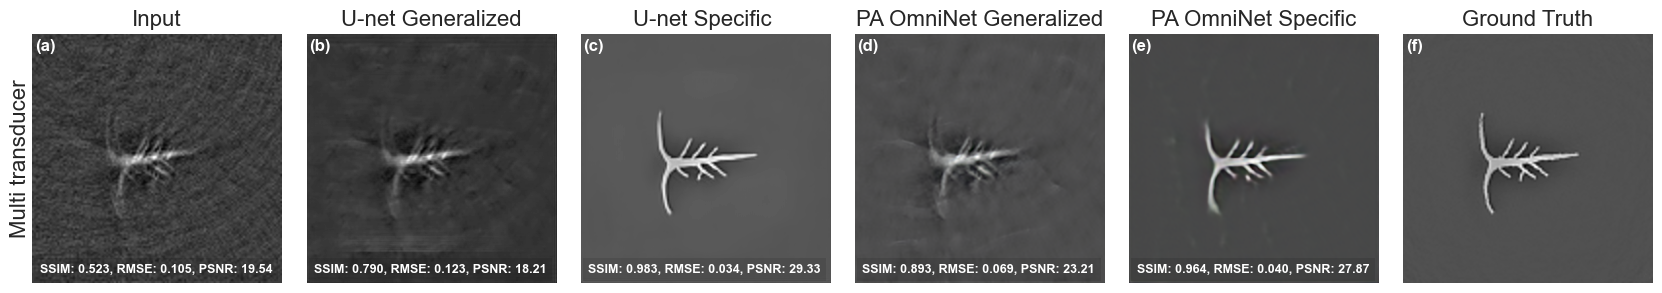

In [9]:

# csv_baseline = 'Baseline_Multi.csv'
csv_baseline = 'Baseline_Multi.csv'
csv_neur = 'Neuralizer_Multi.csv'
csv_neur_specific = 'Neuralizer_Multi_Multi.csv'
# csv_neur_specific = 'Neuralizer_Single_Single.csv'
csv_unet_semi = 'Unet_Semi_on_Multi.csv'
csv_unet_specific = 'Unet_Multi_on_Multi.csv'

specific_model_unet = Unet3hzMultiModel
specific_model_neuralizer = NeuralizerMulti

# with open(csv_baseline, mode="a", newline="") as csv_baseline_file:
#     writer = csv.writer(csv_baseline_file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])
#
# with open(csv_neur, mode="a", newline="") as neuralizer_file:
#     writer = csv.writer(neuralizer_file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])
#
# with open(csv_neur_specific, mode="a", newline="") as neuralizer_specific_file:
#     writer = csv.writer(neuralizer_specific_file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])
#
# with open(csv_unet_specific, mode="a", newline="") as Unet_specific_file:
#     writer = csv.writer(Unet_specific_file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])
#
# with open(csv_unet_semi, mode="a", newline="") as Unet_Semi_file:
#     writer = csv.writer(Unet_Semi_file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])

for i in range(1):
    input_Unet = X_test_Unet[i]
    input_Unet = input_Unet.float()
    input_Unet = input_Unet.unsqueeze(0)
    input_Unet = input_Unet.unsqueeze(0)
    input_Neur = X_test_Neur[i]

    ground_truth_Unet = y_test_Unet[i]
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Neur = y_test_Neur[i]

    output_Neur = model.forward(input_Neur.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))
    output_Neur_specific = specific_model_neuralizer.forward(input_Neur.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))
    output_Unet_Semi = Unet_Semi_model(input_Unet)
    output_Unet_Specific = specific_model_unet(input_Unet)

    normalized_output_Neur = (output_Neur - output_Neur.min()) / (output_Neur.max() - output_Neur.min())
    normalized_output_Neur_specific = (output_Neur_specific - output_Neur_specific.min()) / (output_Neur_specific.max() - output_Neur_specific.min())
    normalized_output_Semi = (output_Unet_Semi - output_Unet_Semi.min()) / (output_Unet_Semi.max() - output_Unet_Semi.min())
    normalized_output_Specific = (output_Unet_Specific - output_Unet_Specific.min()) / (output_Unet_Specific.max() - output_Unet_Specific.min())

    rmse_val_base = compute_rmse(ground_truth_Neur, input_Neur)
    psnr_val_base = compute_psnr(ground_truth_Neur, input_Neur)
    ssim_val_base = ssim(ground_truth_Neur.unsqueeze(0), input_Neur.unsqueeze(0)).item()

    rmse_val_neur = compute_rmse(ground_truth_Neur, normalized_output_Neur.squeeze(0))
    psnr_val_neur = compute_psnr(ground_truth_Neur, normalized_output_Neur.squeeze(0))
    ssim_val_neur = ssim(ground_truth_Neur.unsqueeze(0), normalized_output_Neur).item()

    rmse_val_neur_specific = compute_rmse(ground_truth_Neur, normalized_output_Neur_specific.squeeze(0))
    psnr_val_neur_specific = compute_psnr(ground_truth_Neur, normalized_output_Neur_specific.squeeze(0))
    ssim_val_neur_specific = ssim(ground_truth_Neur.unsqueeze(0), normalized_output_Neur_specific).item()

    rmse_semi = compute_rmse(ground_truth_Unet, normalized_output_Semi)
    psnr_semi = compute_psnr(ground_truth_Unet, normalized_output_Semi)
    ssim_semi = ssim(ground_truth_Unet, normalized_output_Semi).item()

    rmse_specific = compute_rmse(ground_truth_Unet, normalized_output_Specific)
    psnr_specific = compute_psnr(ground_truth_Unet, normalized_output_Specific)
    ssim_specific = ssim(ground_truth_Unet, normalized_output_Specific).item()

    normalized_output_Neur_img = normalized_output_Neur.squeeze().permute(1,2,0).cpu().detach().numpy()
    normalized_output_Neur_img_specific = normalized_output_Neur_specific.squeeze().permute(1,2,0).cpu().detach().numpy()
    normalized_output_Semi_img = normalized_output_Semi.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    normalized_output_Specific_img = normalized_output_Specific.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    ground_truth_img = ground_truth_Unet.squeeze().cpu().numpy()

    titles = ['Input', 'U-net Generalized',
              'U-net Specific ', 'PA OmniNet Generalized', 'PA OmniNet Specific', 'Ground Truth']
    images = [X_test[i], normalized_output_Semi_img, normalized_output_Specific_img, normalized_output_Neur_img, normalized_output_Neur_img_specific, y_test[i]]
    metrics = [
    f"SSIM: {ssim_val_base:.3f}, RMSE: {rmse_val_base:.3f}, PSNR: {psnr_val_base:.2f}",
    f"SSIM: {ssim_semi:.3f}, RMSE: {rmse_semi:.3f}, PSNR: {psnr_semi:.2f}",
    f"SSIM: {ssim_specific:.3f}, RMSE: {rmse_specific:.3f}, PSNR: {psnr_specific:.2f}",
    f"SSIM: {ssim_val_neur:.3f}, RMSE: {rmse_val_neur:.3f}, PSNR: {psnr_val_neur:.2f}",
    f"SSIM: {ssim_val_neur_specific:.3f}, RMSE: {rmse_val_neur_specific:.3f}, PSNR: {psnr_val_neur_specific:.2f}",
    "Ground Truth"]

    plt.figure(figsize=(18, 6))
    alphabet = string.ascii_lowercase[:len(images)]
    for idx, (img, metric, letter) in enumerate(zip(images, metrics, alphabet)):
        ax = plt.subplot(1, 6, idx + 1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        ax.text(0.01, 0.95, f"({letter})", fontsize=12, va='center', ha='left', color='white', fontweight='bold', transform=ax.transAxes)

        if idx % 6 == 0:
            row_label = ['Multi transducer'][idx // 6]
            ax.text(-.05, 0.5, row_label, fontsize=16, va='center', ha='center', rotation='vertical', transform=ax.transAxes)

        if idx < 6:
            plt.title(titles[idx], fontsize=16)

        if metric != "Ground Truth":
            ax.text(0.03, 0.03, metric, fontsize=9, color="white",
                    bbox=dict(facecolor='black', alpha=0.1, edgecolor='none'),
                    va="bottom", ha="left", transform=ax.transAxes ,fontweight='bold')

    plt.subplots_adjust(left=0.05, right=0.95, top=0.85, bottom=0.15, wspace=0.1, hspace=0.1)
    plt.show()
